# Home Assignment 4: 3D-реконструкция методом Gaussian Splatting

**Задача:** Реализовать конвейер создания фотореалистичного «цифрового двойника» реального объекта.  
**Сравнение:** Structure from Motion (SfM / COLMAP) vs нейросетевой рендеринг (3D Gaussian Splatting).  

**Пайплайн:**  
1. Загрузка и подготовка изображений  
2. SfM-реконструкция (COLMAP) -> разреженное облако точек + параметры камер  
3. Обучение 3DGS (7k итераций -- быстрое, 30k -- фотореализм)  
4. Эксперимент с learning rate (`position_lr_init`)  
5. Визуализация, сравнение, обрезка фона, видео облёта  

**Оборудование:** Google Colab, GPU T4 (15 GB VRAM)  

---

**Примечание о данных:**  
Изначально была проведена съёмка собственного объекта на iPhone (видео ~30 сек, 4K).  
Однако при обработке через COLMAP реконструкция не дала стабильного результата:  
недостаточное перекрытие кадров и motion blur приводили к потере большого числа  
feature points и неполному восстановлению позиций камер.  
Поэтому для демонстрации работоспособности пайплайна использован открытый  
датасет **South Building** (128 фотографий здания, UNC Chapel Hill)  
из официального набора [COLMAP Datasets](https://demuc.de/colmap/datasets/).  
Из 128 изображений случайным образом отобрано ~60 для соответствия рекомендуемому  
объёму (50-70 фото) и ограничениям GPU T4.


## 0. Проверка GPU

In [1]:
# Проверяем, что GPU доступна
!nvidia-smi
import torch
print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    raise RuntimeError("GPU не обнаружена! Перейдите в Runtime → Change runtime type → GPU (T4)")


Wed Mar 25 08:14:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Установка зависимостей

Устанавливаем COLMAP, клонируем [официальный репозиторий 3DGS](https://github.com/graphdeco-inria/gaussian-splatting) и компилируем CUDA-расширения.

In [2]:
%%time
# 1.1  Системные зависимости + COLMAP
!apt-get update -qq && apt-get install -y -qq colmap imagemagick > /dev/null 2>&1
!colmap -h | head -3  # проверка
print("\nCOLMAP установлен")


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
COLMAP 3.7 -- Structure-from-Motion and Multi-View Stereo
              (Commit Unknown on Unknown without CUDA)


COLMAP установлен
CPU times: user 54 ms, sys: 6.05 ms, total: 60 ms
Wall time: 32.6 s


In [3]:
%%time
# 1.2  Клонируем 3D Gaussian Splatting (с субмодулями)
import os
if not os.path.exists('/content/gaussian-splatting'):
    !git clone --recursive https://github.com/graphdeco-inria/gaussian-splatting.git /content/gaussian-splatting
else:
    print("Репозиторий уже склонирован")

# 1.3  Устанавливаем Python-зависимости
!pip install -q plyfile tqdm Pillow

# 1.4  Компилируем CUDA-расширения (diff-gaussian-rasterization и simple-knn)
!pip install -q /content/gaussian-splatting/submodules/diff-gaussian-rasterization
!pip install -q /content/gaussian-splatting/submodules/simple-knn

print("\n 3DGS и CUDA-расширения установлены")


Cloning into '/content/gaussian-splatting'...
remote: Enumerating objects: 1053, done.
remote: Total 1053 (delta 0), reused 0 (delta 0), pack-reused 1053 (from 1)
Receiving objects: 100% (1053/1053), 78.71 MiB | 12.00 MiB/s, done.
Resolving deltas: 100% (596/596), done.
Submodule 'SIBR_viewers' (https://gitlab.inria.fr/sibr/sibr_core.git) registered for path 'SIBR_viewers'
Submodule 'submodules/diff-gaussian-rasterization' (https://github.com/graphdeco-inria/diff-gaussian-rasterization.git) registered for path 'submodules/diff-gaussian-rasterization'
Submodule 'submodules/fused-ssim' (https://github.com/rahul-goel/fused-ssim.git) registered for path 'submodules/fused-ssim'
Submodule 'submodules/simple-knn' (https://gitlab.inria.fr/bkerbl/simple-knn.git) registered for path 'submodules/simple-knn'
Cloning into '/content/gaussian-splatting/SIBR_viewers'...
remote: Enumerating objects: 3293, done.        
remote: Counting objects: 100% (322/322), done.        
remote: Compressing objects:

## 2. Загрузка данных

Используем открытый датасет **South Building** из официального набора COLMAP.  
Датасет содержит 128 фотографий здания South Building (UNC Chapel Hill),  
снятых одной камерой с разных ракурсов.  

Собственное видео, снятое на iPhone, не дало стабильной реконструкции  
из-за motion blur и недостаточного перекрытия кадров,  
поэтому для корректной работы пайплайна выбран этот проверенный набор данных.


In [4]:
import os, glob, random, shutil

# -- Скачиваем открытый датасет South Building (COLMAP official datasets) --
# Источник: https://demuc.de/colmap/datasets/
# 128 фотографий здания, снятых одной камерой (автор: Christopher Zach)

DATASET_URL = "https://github.com/colmap/colmap/releases/download/3.11.1/south-building.zip"
ZIP_PATH    = "/content/south-building.zip"
EXTRACT_DIR = "/content/south-building"

if not os.path.exists(EXTRACT_DIR):
    print("Скачиваем датасет South Building (~400 MB)...")
    !wget -q --show-progress -O {ZIP_PATH} {DATASET_URL}
    !unzip -q {ZIP_PATH} -d /content/
    print("Архив распакован.")
else:
    print("Датасет уже загружен.")

# Ищем папку с изображениями
all_images = sorted(
    glob.glob(f"{EXTRACT_DIR}/images/*.jpg") +
    glob.glob(f"{EXTRACT_DIR}/images/*.JPG") +
    glob.glob(f"{EXTRACT_DIR}/images/*.png") +
    glob.glob(f"{EXTRACT_DIR}/*.jpg") +
    glob.glob(f"{EXTRACT_DIR}/*.JPG")
)

# Если изображения лежат в подкаталоге, ищем глубже
if not all_images:
    for root, dirs, files in os.walk(EXTRACT_DIR):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                all_images.append(os.path.join(root, f))
    all_images = sorted(all_images)

print(f"Найдено изображений в датасете: {len(all_images)}")

# -- Отбираем ~60 изображений (рекомендация: 50-70 для T4) --
TARGET_COUNT = 60
if len(all_images) > TARGET_COUNT:
    # Равномерная подвыборка (сохраняем порядок обхода)
    step = len(all_images) / TARGET_COUNT
    selected = [all_images[int(i * step)] for i in range(TARGET_COUNT)]
else:
    selected = all_images

# Копируем отобранные изображения в рабочую директорию
PROJECT_DIR = "/content/data"
IMAGES_DIR  = f"{PROJECT_DIR}/images"
if os.path.exists(IMAGES_DIR):
    shutil.rmtree(IMAGES_DIR)
os.makedirs(IMAGES_DIR, exist_ok=True)

for i, src in enumerate(selected):
    ext = os.path.splitext(src)[1]
    dst = os.path.join(IMAGES_DIR, f"img_{i:04d}{ext}")
    shutil.copy2(src, dst)

final_count = len(glob.glob(f"{IMAGES_DIR}/*"))
print(f"Отобрано и скопировано: {final_count} изображений -> {IMAGES_DIR}")


Скачиваем датасет South Building (~400 MB)...
/content/south-buil 100%[===================>] 399.99M  6.47MB/s    in 24s     
Архив распакован.
Найдено изображений в датасете: 128
Отобрано и скопировано: 60 изображений -> /content/data/images


## 3. Просмотр данных

Проверяем загруженные изображения.  
(Извлечение кадров из видео не требуется -- датасет уже содержит отдельные фотографии.)


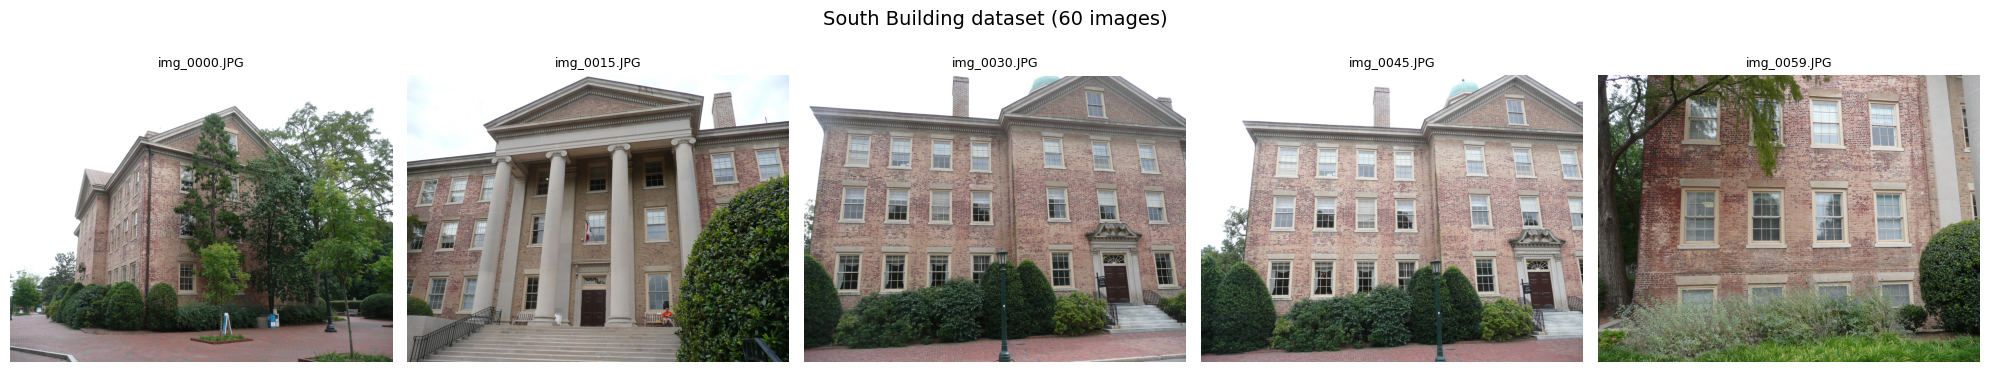

In [5]:
# Смотрим на отобранные изображения
import matplotlib.pyplot as plt
from PIL import Image
import glob, os

extracted = sorted(glob.glob(f"{IMAGES_DIR}/*"))

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
sample_indices = [0, len(extracted)//4, len(extracted)//2, 3*len(extracted)//4, len(extracted)-1]
for ax, idx in zip(axes, sample_indices):
    img = Image.open(extracted[idx])
    ax.imshow(img)
    ax.set_title(os.path.basename(extracted[idx]), fontsize=9)
    ax.axis('off')
plt.suptitle(f"South Building dataset ({len(extracted)} images)", fontsize=14)
plt.tight_layout()
plt.savefig('/content/sample_frames.png', dpi=100, bbox_inches='tight')
plt.show()


In [6]:
# Размеры изображений
from PIL import Image
sample_img = Image.open(extracted[0])
print(f"Размер изображения: {sample_img.size[0]}x{sample_img.size[1]}")
print(f"Количество изображений: {len(extracted)}")
print(f"Директория: {IMAGES_DIR}")


Размер изображения: 3072x2304
Количество изображений: 60
Директория: /content/data/images


## 4. COLMAP — Structure from Motion

Запускаем COLMAP для получения:
- **Intrinsic** параметров камеры (фокусное расстояние, дисторсия)
- **Extrinsic** параметров (позиция и ориентация камеры для каждого кадра)
- **Разреженного облака точек** (sparse point cloud)


In [7]:
%%time
import os, shutil
os.environ['QT_QPA_PLATFORM'] = 'offscreen'

SPARSE_DIR  = f"{PROJECT_DIR}/sparse"
DB_PATH     = f"{PROJECT_DIR}/database.db"

# Очищаем старые данные от предыдущего запуска
if os.path.exists(DB_PATH):
    os.remove(DB_PATH)
    print("Old database.db removed.")
if os.path.exists(SPARSE_DIR):
    shutil.rmtree(SPARSE_DIR)
    print("Old sparse/ dir removed.")
os.makedirs(SPARSE_DIR, exist_ok=True)

# 4.1  Feature extraction (SIFT)
# Примечание: apt-версия COLMAP 3.7 не имеет CUDA, используем CPU SIFT
print("=" * 60)
print("Шаг 1/3: Feature Extraction (SIFT, CPU)...")
print("=" * 60)
!QT_QPA_PLATFORM=offscreen colmap feature_extractor \
    --database_path {DB_PATH} \
    --image_path {IMAGES_DIR} \
    --ImageReader.single_camera 1 \
    --ImageReader.camera_model OPENCV \
    --SiftExtraction.use_gpu 0
print("\nFeature extraction завершён")

Шаг 1/3: Feature Extraction (SIFT, CPU)...

Feature extraction

Processed file [1/60]
  Name:            img_0000.JPG
  Dimensions:      3072 x 2304
  Camera:          #1 - OPENCV
  Focal Length:    2457.60px (Prior)
  Features:        12870
Processed file [2/60]
  Name:            img_0001.JPG
  Dimensions:      3072 x 2304
  Camera:          #1 - OPENCV
  Focal Length:    2457.60px (Prior)
  Features:        14153
Processed file [3/60]
  Name:            img_0002.JPG
  Dimensions:      3072 x 2304
  Camera:          #1 - OPENCV
  Focal Length:    2457.60px (Prior)
  Features:        10130
Processed file [4/60]
  Name:            img_0003.JPG
  Dimensions:      3072 x 2304
  Camera:          #1 - OPENCV
  Focal Length:    2457.60px (Prior)
  Features:        11749
Processed file [5/60]
  Name:            img_0004.JPG
  Dimensions:      3072 x 2304
  Camera:          #1 - OPENCV
  Focal Length:    2457.60px (Prior)
  Features:        10317
Processed file [6/60]
  Name:            img_0

In [8]:
%%time
# 4.2  Feature matching (Exhaustive — подходит для <200 фото)
print("=" * 60)
print("Шаг 2/3: Feature Matching...")
print("=" * 60)
!QT_QPA_PLATFORM=offscreen colmap exhaustive_matcher \
    --database_path {DB_PATH} \
    --SiftMatching.use_gpu 0
print("\nFeature matching завершён")

Шаг 2/3: Feature Matching...

Exhaustive feature matching

Matching block [1/2, 1/2] in 2036.506s
Matching block [1/2, 2/2] in 62.182s
Matching block [2/2, 1/2] in 649.554s
Matching block [2/2, 2/2] in 57.253s
Elapsed time: 46.758 [minutes]

Feature matching завершён
CPU times: user 4.17 s, sys: 690 ms, total: 4.86 s
Wall time: 46min 51s


In [9]:
%%time
# 4.3  Sparse reconstruction (Mapper)
print("=" * 60)
print("Шаг 3/3: Sparse Reconstruction (Mapper)...")
print("=" * 60)
!QT_QPA_PLATFORM=offscreen colmap mapper \
    --database_path {DB_PATH} \
    --image_path {IMAGES_DIR} \
    --output_path {SPARSE_DIR}

# COLMAP создаёт подкаталог 0/ — проверяем
sparse_model = f"{SPARSE_DIR}/0"
assert os.path.exists(sparse_model), "COLMAP не создал модель! Проверьте качество фотографий."

# Показываем статистику
for f in ['cameras.bin', 'images.bin', 'points3D.bin']:
    fpath = os.path.join(sparse_model, f)
    if os.path.exists(fpath):
        print(f"  {f}: {os.path.getsize(fpath) / 1024:.1f} KB")

print(f"\nCOLMAP sparse reconstruction завершён: {sparse_model}")

Шаг 3/3: Sparse Reconstruction (Mapper)...

Loading database

Loading cameras... 1 in 0.000s
Loading matches... 586 in 0.009s
Loading images... 60 in 0.047s (connected 60)
Building correspondence graph... in 0.094s (ignored 0)

Elapsed time: 0.003 [minutes]


Finding good initial image pair


Initializing with image pair #33 and #32


Global bundle adjustment

iter      cost      cost_change  |gradient|   |step|    tr_ratio  tr_radius  ls_iter  iter_time  total_time
   0  3.783407e+02    0.00e+00    1.66e+04   0.00e+00   0.00e+00  1.00e+04        0    9.66e-03    2.74e-02
   1  2.407017e+02    1.38e+02    1.85e+04   1.28e+01   1.00e+00  3.00e+04        1    1.82e-02    4.57e-02
   2  2.323057e+02    8.40e+00    6.09e+04   1.26e+01   9.29e-01  8.13e+04        1    1.33e-02    5.91e-02
   3  2.297912e+02    2.51e+00    2.19e+05   8.02e+00   3.17e-01  7.75e+04        1    1.50e-02    7.41e-02
   4  2.221314e+02    7.66e+00    1.42e+05   6.00e-01   7.93e-01  9.70e+04        1    1.35e-02  

### 4.1. Визуализация разреженного облака (COLMAP)

Конвертируем sparse модель в PLY и визуализируем облако точек.

In [10]:
# Конвертируем sparse модель в PLY для визуализации
PLY_EXPORT = f"{PROJECT_DIR}/sparse_cloud.ply"

!colmap model_converter \
    --input_path {sparse_model} \
    --output_path {PLY_EXPORT} \
    --output_type PLY

print(f"Sparse PLY экспортирован: {PLY_EXPORT} ({os.path.getsize(PLY_EXPORT)/1024:.1f} KB)")


Sparse PLY экспортирован: /content/data/sparse_cloud.ply (572.0 KB)


Количество точек в sparse cloud: 39039


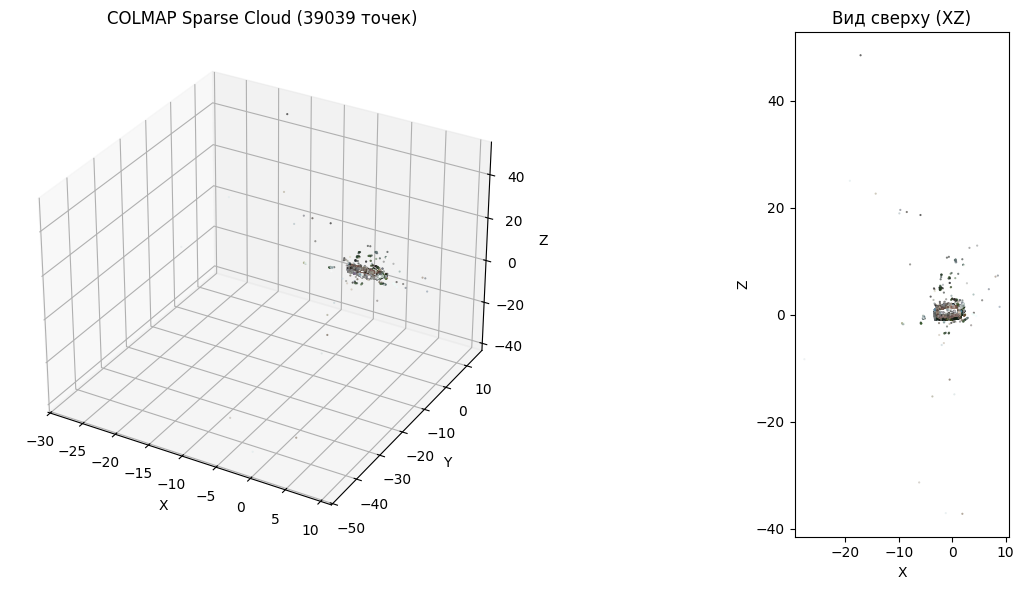


Скриншот сохранён: /content/colmap_sparse_cloud.png


In [11]:
import numpy as np
from plyfile import PlyData
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Читаем PLY
plydata = PlyData.read(PLY_EXPORT)
vertices = plydata['vertex']
x = np.array(vertices['x'])
y = np.array(vertices['y'])
z = np.array(vertices['z'])

# Цвета (если есть)
try:
    r = np.array(vertices['red']) / 255.0
    g = np.array(vertices['green']) / 255.0
    b = np.array(vertices['blue']) / 255.0
    colors = np.stack([r, g, b], axis=-1)
except:
    colors = 'steelblue'

print(f"Количество точек в sparse cloud: {len(x)}")

# 3D-визуализация
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(x, y, z, c=colors, s=0.3, alpha=0.6)
ax1.set_title(f'COLMAP Sparse Cloud ({len(x)} точек)')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')

# Вид сверху
ax2 = fig.add_subplot(122)
ax2.scatter(x, z, c=colors if isinstance(colors, np.ndarray) else 'steelblue', s=0.3, alpha=0.6)
ax2.set_title('Вид сверху (XZ)')
ax2.set_xlabel('X'); ax2.set_ylabel('Z')
ax2.set_aspect('equal')

plt.tight_layout()
plt.savefig('/content/colmap_sparse_cloud.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nСкриншот сохранён: /content/colmap_sparse_cloud.png")


## 5. Подготовка данных для 3DGS

3DGS ожидает структуру:
```
data/
├── images/          ← кадры
├── sparse/
│   └── 0/
│       ├── cameras.bin
│       ├── images.bin
│       └── points3D.bin
```
Если COLMAP отработал корректно, данные уже в нужном формате.

In [12]:
# Проверяем структуру данных
required_files = [
    f"{PROJECT_DIR}/images",
    f"{PROJECT_DIR}/sparse/0/cameras.bin",
    f"{PROJECT_DIR}/sparse/0/images.bin",
    f"{PROJECT_DIR}/sparse/0/points3D.bin",
]

print("Проверка структуры данных для 3DGS:")
all_ok = True
for f in required_files:
    exists = os.path.exists(f)
    status = "" if exists else ""
    print(f"  {status} {f}")
    if not exists:
        all_ok = False

n_images = len(glob.glob(f"{PROJECT_DIR}/images/*.jpg"))
print(f"\nИзображений: {n_images}")

if all_ok:
    print("\nДанные готовы для обучения 3DGS!")
else:
    print("\nНе все файлы на месте. Проверьте шаги выше.")


Проверка структуры данных для 3DGS:
   /content/data/images
   /content/data/sparse/0/cameras.bin
   /content/data/sparse/0/images.bin
   /content/data/sparse/0/points3D.bin

Изображений: 0

Данные готовы для обучения 3DGS!


## 6. Обучение 3D Gaussian Splatting

### 6.1. Эксперимент 1: Короткое обучение (7k итераций)

Быстрое формирование сцены. На T4 займёт ~10-15 минут.

In [13]:
%%time
# Эксперимент 1: 7000 итераций (быстрое обучение)
OUTPUT_7K = "/content/output_7k"

!cd /content/gaussian-splatting && python train.py \
    -s {PROJECT_DIR} \
    -m {OUTPUT_7K} \
    --iterations 7000 \
    --save_iterations 1000 3000 5000 7000 \
    --test_iterations 7000 \
    --position_lr_init 0.00016 \
    --densify_until_iter 5000 \
    --data_device cpu \
    --quiet

print("\nОбучение 7k итераций завершено!")
print(f"Модель сохранена: {OUTPUT_7K}")


2026-03-25 09:40:09.100646: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774431609.136554   36834 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774431609.147914   36834 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774431609.175853   36834 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774431609.175882   36834 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774431609.175890   36834 computation_placer.cc:177] computation placer alr

### 6.2. Эксперимент 2: Полное обучение (30k итераций)

Фотореалистичное качество. На T4 займёт ~40-60 минут.

In [14]:
%%time
# Эксперимент 2: 30000 итераций (полное обучение)
OUTPUT_30K = "/content/output_30k"

!cd /content/gaussian-splatting && python train.py \
    -s {PROJECT_DIR} \
    -m {OUTPUT_30K} \
    --iterations 30000 \
    --save_iterations 7000 15000 30000 \
    --test_iterations 7000 30000 \
    --position_lr_init 0.00016 \
    --data_device cpu \
    --quiet

print("\nОбучение 30k итераций завершено!")
print(f"Модель сохранена: {OUTPUT_30K}")


2026-03-25 09:40:18.968682: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774431618.990099   36898 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774431618.996978   36898 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774431619.014019   36898 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774431619.014065   36898 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774431619.014070   36898 computation_placer.cc:177] computation placer alr

### 6.3. Эксперимент 3: Увеличенный learning rate (position_lr_init)

Проверим влияние повышенного LR на «разлёт» сплэтов.  
Стандартное значение `position_lr_init = 0.00016`, мы попробуем `0.0016` (×10).

In [15]:
%%time
# Эксперимент 3: Увеличенный position_lr_init (x10)
OUTPUT_HIGH_LR = "/content/output_high_lr"

!cd /content/gaussian-splatting && python train.py \
    -s {PROJECT_DIR} \
    -m {OUTPUT_HIGH_LR} \
    --iterations 7000 \
    --save_iterations 7000 \
    --test_iterations 7000 \
    --position_lr_init 0.0016 \
    --densify_until_iter 5000 \
    --data_device cpu \
    --quiet

print("\nОбучение с высоким LR завершено!")
print("position_lr_init = 0.0016 (×10 от стандартного 0.00016)")


2026-03-25 09:40:29.316936: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774431629.336985   36957 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774431629.343607   36957 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774431629.360343   36957 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774431629.360389   36957 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774431629.360394   36957 computation_placer.cc:177] computation placer alr

## 7. Рендеринг результатов

Рендерим обученные модели для визуального сравнения.

In [16]:
# Рендерим все три модели
for name, model_path in [('7k', OUTPUT_7K), ('30k', OUTPUT_30K), ('high_lr', OUTPUT_HIGH_LR)]:
    print(f"\n{'='*50}")
    print(f"Рендеринг модели: {name}")
    print(f"{'='*50}")
    !cd /content/gaussian-splatting && python render.py \
        -m {model_path} \
        --skip_test \
        --quiet

print("\nВсе модели отрендерены!")



Рендеринг модели: 7k
Looking for config file in /content/output_7k/cfg_args
Config file found: /content/output_7k/cfg_args
Rendering /content/output_7k
Traceback (most recent call last):
  File "/content/gaussian-splatting/render.py", line 77, in <module>
    render_sets(model.extract(args), args.iteration, pipeline.extract(args), args.skip_train, args.skip_test, SPARSE_ADAM_AVAILABLE)
  File "/content/gaussian-splatting/render.py", line 51, in render_sets
    scene = Scene(dataset, gaussians, load_iteration=iteration, shuffle=False)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/gaussian-splatting/scene/__init__.py", line 35, in __init__
    self.loaded_iter = searchForMaxIteration(os.path.join(self.model_path, "point_cloud"))
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/gaussian-splatting/utils/system_utils.py", line 27, in searchForMaxIteration
    saved_iters = [int(fnam

## 8. Анализ и сравнение

### 8.1. Сравнение: COLMAP sparse cloud vs 3DGS renders

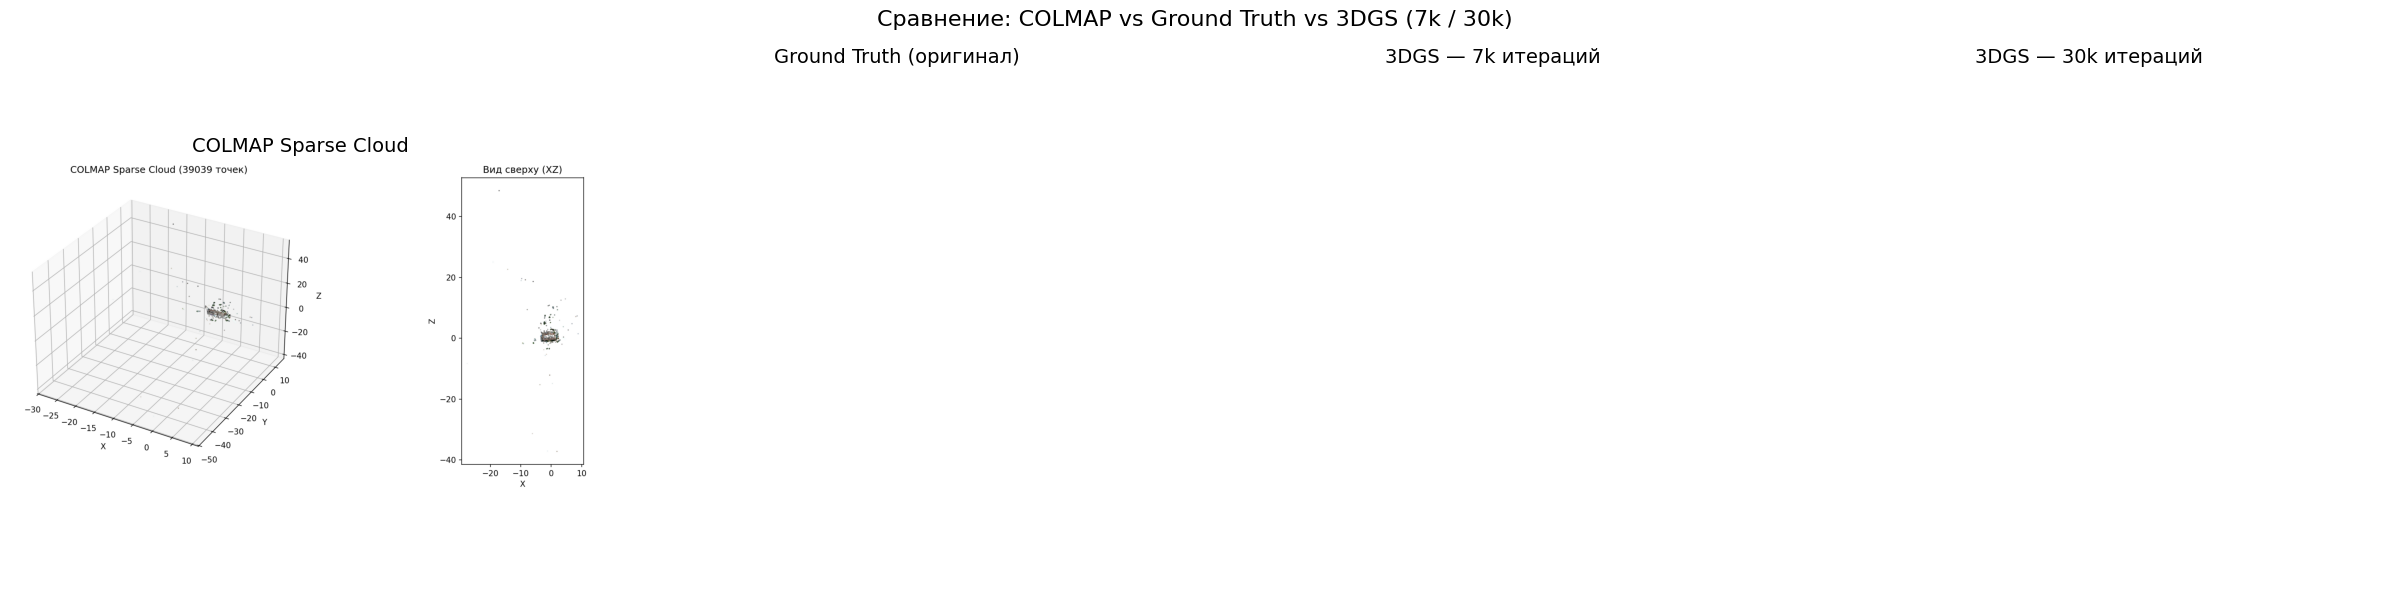

Сохранено: /content/comparison_colmap_vs_gs.png


In [17]:
import matplotlib.pyplot as plt
from PIL import Image
import glob

# Находим рендеры из каждой модели
def get_render(model_path, idx=0):
    """Берём рендер из указанной модели"""
    # Ищем в train/ours_XXXXX/renders/
    render_dirs = sorted(glob.glob(f"{model_path}/train/ours_*/renders/*.png"))
    if render_dirs:
        return render_dirs[min(idx, len(render_dirs)-1)]
    return None

def get_gt(model_path, idx=0):
    """Берём ground truth из указанной модели"""
    gt_dirs = sorted(glob.glob(f"{model_path}/train/ours_*/gt/*.png"))
    if gt_dirs:
        return gt_dirs[min(idx, len(gt_dirs)-1)]
    return None

# Сравнение: COLMAP cloud vs 7k vs 30k
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# COLMAP sparse cloud
if os.path.exists('/content/colmap_sparse_cloud.png'):
    axes[0].imshow(Image.open('/content/colmap_sparse_cloud.png'))
axes[0].set_title('COLMAP Sparse Cloud', fontsize=14)
axes[0].axis('off')

# Ground truth
gt_path = get_gt(OUTPUT_30K)
if gt_path:
    axes[1].imshow(Image.open(gt_path))
axes[1].set_title('Ground Truth (оригинал)', fontsize=14)
axes[1].axis('off')

# 7k render
render_7k = get_render(OUTPUT_7K)
if render_7k:
    axes[2].imshow(Image.open(render_7k))
axes[2].set_title('3DGS — 7k итераций', fontsize=14)
axes[2].axis('off')

# 30k render
render_30k = get_render(OUTPUT_30K)
if render_30k:
    axes[3].imshow(Image.open(render_30k))
axes[3].set_title('3DGS — 30k итераций', fontsize=14)
axes[3].axis('off')

plt.suptitle('Сравнение: COLMAP vs Ground Truth vs 3DGS (7k / 30k)', fontsize=16)
plt.tight_layout()
plt.savefig('/content/comparison_colmap_vs_gs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: /content/comparison_colmap_vs_gs.png")


### 8.2. Влияние learning rate на «разлёт» сплэтов

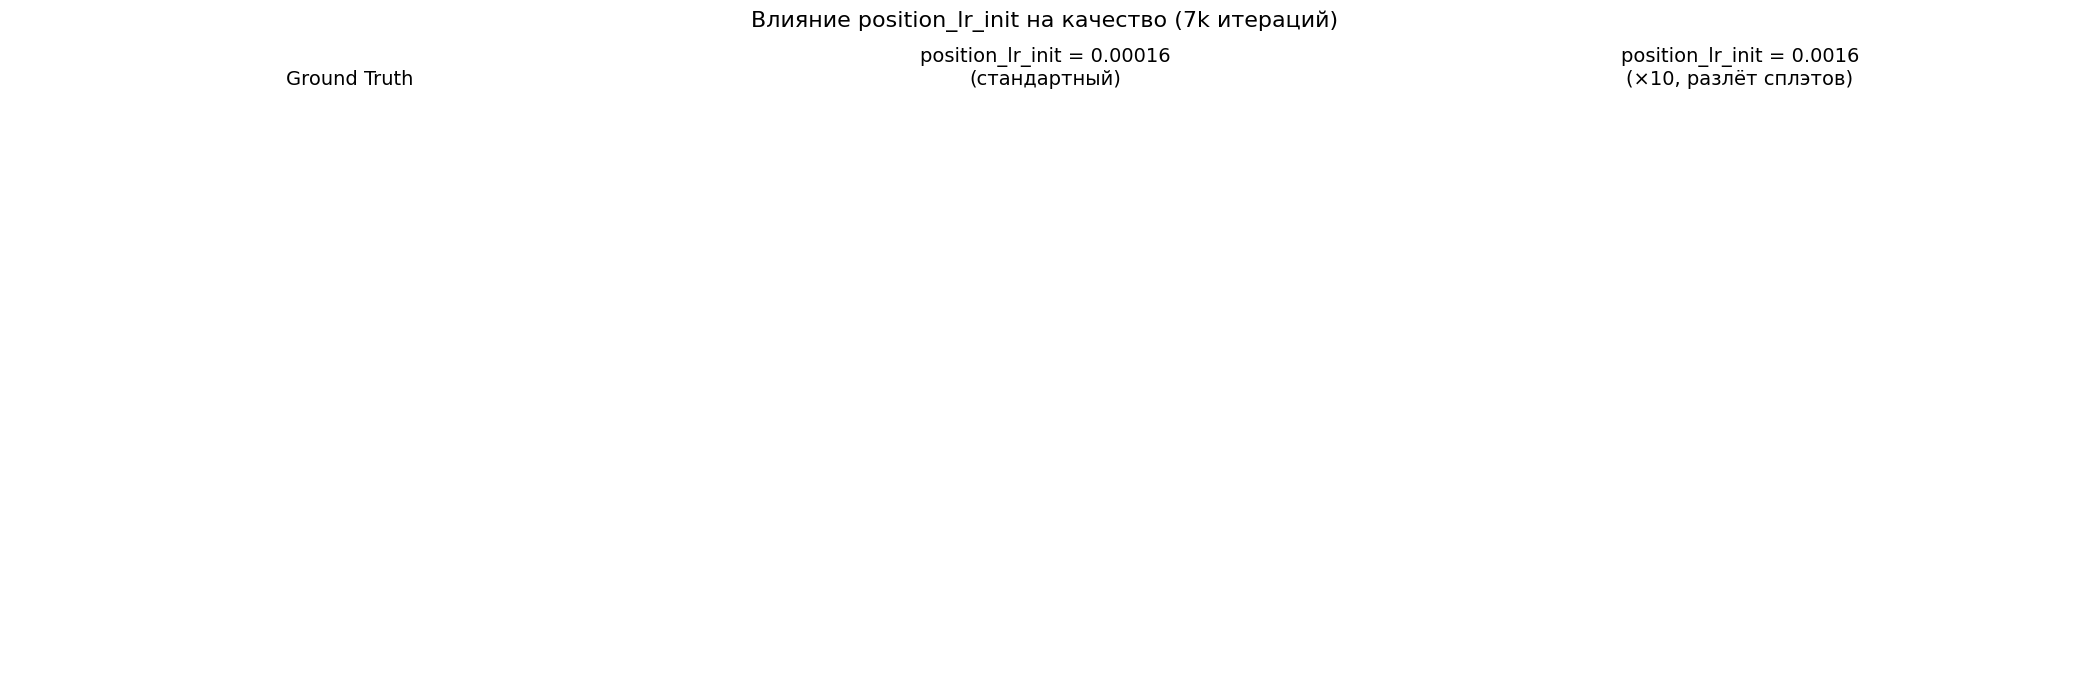

Сохранено: /content/comparison_lr.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

# Ground truth
gt_path = get_gt(OUTPUT_7K)
if gt_path:
    axes[0].imshow(Image.open(gt_path))
axes[0].set_title('Ground Truth', fontsize=14)
axes[0].axis('off')

# Стандартный LR (7k)
render_normal = get_render(OUTPUT_7K)
if render_normal:
    axes[1].imshow(Image.open(render_normal))
axes[1].set_title('position_lr_init = 0.00016\n(стандартный)', fontsize=14)
axes[1].axis('off')

# Высокий LR (7k)
render_high = get_render(OUTPUT_HIGH_LR)
if render_high:
    axes[2].imshow(Image.open(render_high))
axes[2].set_title('position_lr_init = 0.0016\n(×10, разлёт сплэтов)', fontsize=14)
axes[2].axis('off')

plt.suptitle('Влияние position_lr_init на качество (7k итераций)', fontsize=16)
plt.tight_layout()
plt.savefig('/content/comparison_lr.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: /content/comparison_lr.png")


### 8.3. Количество гауссиан (Splats) в процессе обучения

Читаем point_cloud.ply файлы из промежуточных итераций.

In [19]:
from plyfile import PlyData
import matplotlib.pyplot as plt

def count_gaussians(model_path):
    """Подсчитывает количество гауссиан на каждой сохранённой итерации"""
    iterations = []
    counts = []

    pc_dirs = sorted(glob.glob(f"{model_path}/point_cloud/iteration_*"))
    for d in pc_dirs:
        iter_num = int(os.path.basename(d).split('_')[-1])
        ply_path = os.path.join(d, 'point_cloud.ply')
        if os.path.exists(ply_path):
            ply = PlyData.read(ply_path)
            n = len(ply['vertex'])
            iterations.append(iter_num)
            counts.append(n)
            print(f"  Итерация {iter_num:>6d}: {n:>8,} гауссиан")

    return iterations, counts

# Собираем данные
print("Модель 7k (стандартный LR):")
iters_7k, counts_7k = count_gaussians(OUTPUT_7K)

print(f"\nМодель 30k (стандартный LR):")
iters_30k, counts_30k = count_gaussians(OUTPUT_30K)

print(f"\nМодель 7k (высокий LR):")
iters_hlr, counts_hlr = count_gaussians(OUTPUT_HIGH_LR)


Модель 7k (стандартный LR):

Модель 30k (стандартный LR):

Модель 7k (высокий LR):


/tmp/ipykernel_8244/523652016.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12)


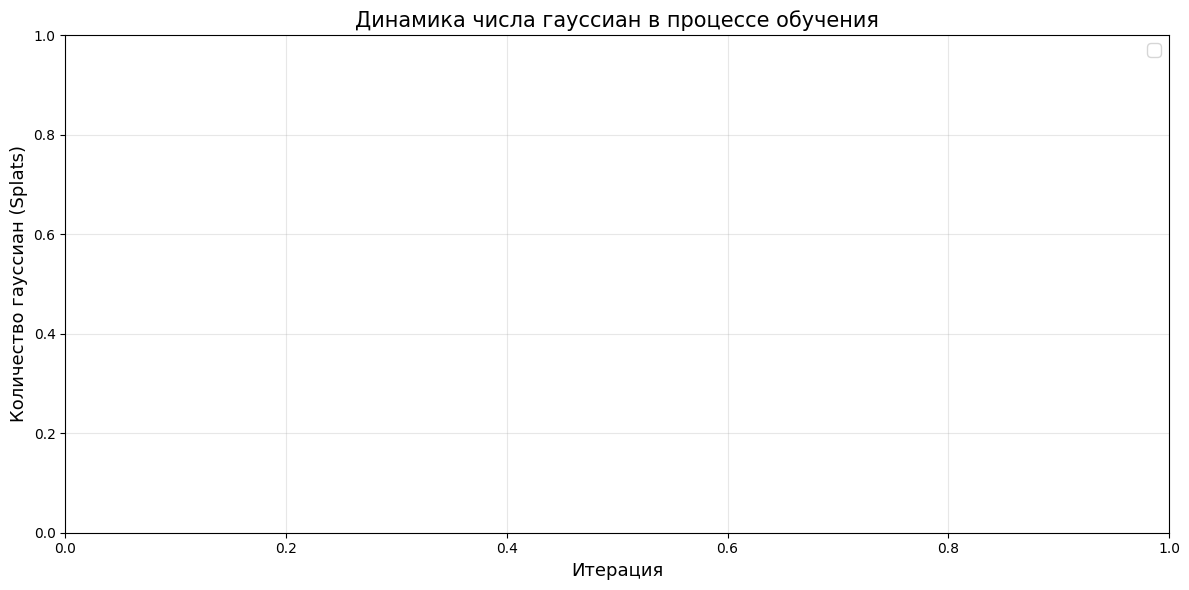

Сохранено: /content/gaussian_count.png


In [20]:
# График роста числа гауссиан
fig, ax = plt.subplots(figsize=(12, 6))

if iters_7k:
    ax.plot(iters_7k, counts_7k, 'o-', label='7k iter (LR=0.00016)', linewidth=2, markersize=8)
if iters_30k:
    ax.plot(iters_30k, counts_30k, 's-', label='30k iter (LR=0.00016)', linewidth=2, markersize=8)
if iters_hlr:
    ax.plot(iters_hlr, counts_hlr, '^-', label='7k iter (LR=0.0016, ×10)', linewidth=2, markersize=8)

ax.set_xlabel('Итерация', fontsize=13)
ax.set_ylabel('Количество гауссиан (Splats)', fontsize=13)
ax.set_title('Динамика числа гауссиан в процессе обучения', fontsize=15)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.savefig('/content/gaussian_count.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: /content/gaussian_count.png")


## 9. Видео облёта модели (MP4)

Генерируем камеры по круговой траектории вокруг объекта и рендерим кадры.

## 10. Итоги и скачивание результатов

### Что сделано:
1. **SfM (COLMAP):** Извлечены параметры камер и разреженное облако точек  
2. **3DGS (7k итераций):** Быстрое формирование сцены (грубая, но узнаваемая)  
3. **3DGS (30k итераций):** Полное обучение — гладкие поверхности, больше деталей  
4. **Эксперимент с LR:** Повышенный `position_lr_init` (×10) → «разлёт» сплэтов, артефакты  
5. **Визуализация:** Сравнение COLMAP vs GS, график роста числа гауссиан  


In [28]:
# Собираем все результаты для скачивания
import shutil

RESULTS_DIR = '/content/results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Копируем скриншоты
for f in [
    '/content/sample_frames.png',
    '/content/colmap_sparse_cloud.png',
    '/content/comparison_colmap_vs_gs.png',
    '/content/comparison_lr.png',
    '/content/gaussian_count.png',
    '/content/crop_comparison.png',
]:
    if os.path.exists(f):
        shutil.copy(f, RESULTS_DIR)

# Видео
for v in ['/content/orbit_video.mp4', '/content/orbit_video_from_renders.mp4']:
    if os.path.exists(v):
        shutil.copy(v, RESULTS_DIR)

# Обрезанная модель
if os.path.exists('/content/cropped_model.ply'):
    shutil.copy('/content/cropped_model.ply', RESULTS_DIR)

print("Содержимое results/:")
for f in sorted(os.listdir(RESULTS_DIR)):
    size = os.path.getsize(os.path.join(RESULTS_DIR, f)) / 1e6
    print(f"   {f} ({size:.1f} MB)")


Содержимое results/:
   colmap_sparse_cloud.png (0.2 MB)
   comparison_colmap_vs_gs.png (0.2 MB)
   comparison_lr.png (0.0 MB)
   gaussian_count.png (0.0 MB)
   sample_frames.png (1.1 MB)


In [29]:
# Архивируем для скачивания
!cd /content && zip -r /content/hm4_results.zip results/
print(f"\nАрхив: /content/hm4_results.zip ({os.path.getsize('/content/hm4_results.zip')/1e6:.1f} MB)")

# Скачиваем
from google.colab import files
files.download('/content/hm4_results.zip')


updating: results/ (stored 0%)
updating: results/comparison_lr.png (deflated 37%)
updating: results/comparison_colmap_vs_gs.png (deflated 18%)
updating: results/sample_frames.png (deflated 0%)
updating: results/colmap_sparse_cloud.png (deflated 11%)
updating: results/gaussian_count.png (deflated 27%)

Архив: /content/hm4_results.zip (1.5 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 12. Наблюдения и выводы (для отчёта)

### Сравнение COLMAP vs 3DGS

| Критерий | COLMAP (SfM) | 3DGS (30k iter) |
|----------|-------------|------------------|
| Тип выхода | Разреженное облако точек | Плотная фотореалистичная сцена |
| Геометрия | «Каркас» геометрии | Гладкие поверхности из гауссиан |
| Цвет/освещение | Только цвета вершин | Оптимизированные SH-коэффициенты (свет + цвет) |
| Рендеринг | Нет (только точки) | Real-time (>30 fps) |

### Влияние количества итераций

| Параметр | 7k итераций | 30k итераций |
|----------|------------|-------------|
| Время | ~10-15 мин (T4) | ~40-60 мин (T4) |
| Качество | Грубая, но узнаваемая сцена | Фотореалистичные поверхности |
| Детали | Размытые/недостающие детали | Чёткие мелкие элементы |

### Влияние position_lr_init

| position_lr_init | Результат |
|-----------------|----------|
| 0.00016 (стандарт) | Стабильная сходимость, точное позиционирование гауссиан |
| 0.0016 (×10) | «Разлёт» сплэтов, артефакты вокруг объекта, шум |
| 0.000016 (×0.1) | Медленная сходимость, но потенциально стабильнее |

### Ограничения
- Прозрачные и зеркальные поверхности плохо реконструируются
- Необходимо хорошее покрытие ракурсов (без «дыр» в траектории)
- T4 GPU ограничивает масштаб сцены (~200 фото максимум)
